# Data Preparation: Telco NPS Prediction

This phase creates the NPS target, cleans the issues identified in `02_data_understanding`, builds the first features, and prepares a train/test split that matches the business problem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
df_services = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_status = pd.read_excel("../data/raw/Telco_customer_churn.xlsx")
df_services = df_services.rename(columns={"customerID": "Customer ID"})
df_raw = df_services.merge(df_status, on="Customer ID", how="inner", validate="1:1")

## Building the NPS Target


### Baseline mapping

In [3]:
baseline_map = {5: "Promoter", 4: "Passive", 3: "Detractor", 2: "Detractor", 1: "Detractor"}
df_raw["NPS_baseline"] = df_raw["Satisfaction Score"].map(baseline_map)

df_raw["NPS_baseline"].value_counts(normalize=True) * 100

NPS_baseline
Detractor    58.284822
Passive      25.401107
Promoter     16.314071
Name: proportion, dtype: float64

As identified during Data Understanding, this mapping creates a highly imbalanced distribution toward detractors (58%) because it groups 3 of the 5 satisfaction levels (1, 2, **and** 3) into the same class.

### Refined mapping

The mapping is refined by treating score 3 as an ambiguous case that should be resolved individually, rather than automatically classifying it as a detractor.

Score 3 is reclassified using `Churn Value`: a neutral customer who eventually churned is treated as a detractor, while a neutral customer who remained with the company is treated as passive.

In [4]:
def refine(row):
    s = row["Satisfaction Score"]
    if s >= 5:
        return "Promoter"
    if s == 4:
        return "Passive"
    if s <= 2:
        return "Detractor"
    # s == 3: cas ambigu, tranché par le comportement réel de churn
    return "Detractor" if row["Churn Value"] == 1 else "Passive"

df_raw["NPS_Category"] = df_raw.apply(refine, axis=1)
df_raw["NPS_Category"].value_counts(normalize=True) * 100

NPS_Category
Passive      57.148942
Detractor    26.536987
Promoter     16.314071
Name: proportion, dtype: float64

In [5]:
df_raw["Satisfaction Score"][df_raw["Satisfaction Score"]==3].index  # score=3 population
df_raw[df_raw["Satisfaction Score"]==3]["Churn Value"].value_counts()

Churn Value
0    2236
1     429
Name: count, dtype: int64

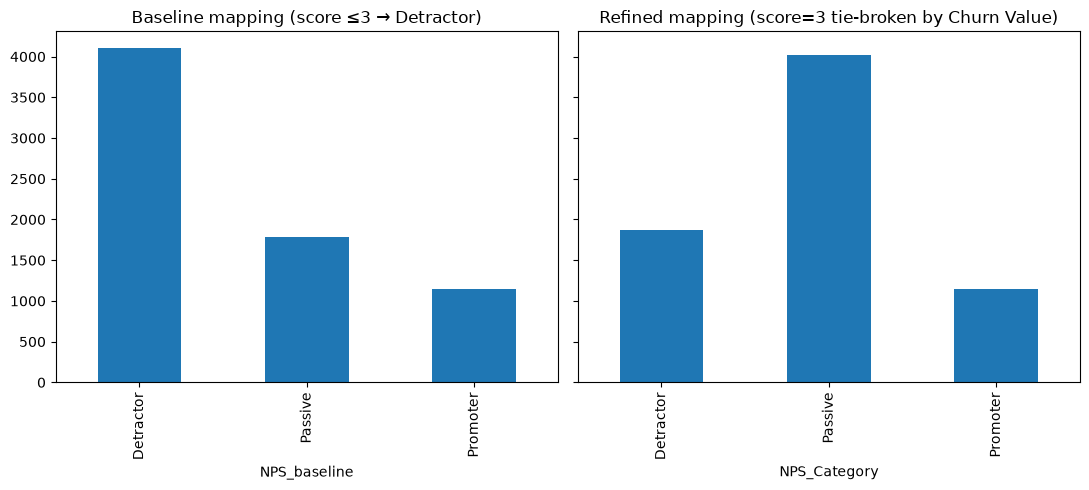

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11,5), sharey=True)
order = ["Detractor", "Passive", "Promoter"]
df_raw["NPS_baseline"].value_counts().reindex(order).plot(kind="bar", ax=axes[0])
axes[0].set_title("Baseline mapping (score ≤3 → Detractor)")
df_raw["NPS_Category"].value_counts().reindex(order).plot(kind="bar", ax=axes[1])
axes[1].set_title("Refined mapping (score=3 tie-broken by Churn Value)")
plt.tight_layout()
plt.show()

### Sensitivity analysis

In [7]:
diff = (df_raw["NPS_baseline"] != df_raw["NPS_Category"]).sum()
print(f"{diff} customers reclassified ({diff/len(df_raw)*100:.1f}%)")

2236 customers reclassified (31.7%)


## Dataset Preparation

### Schema: keep / drop / transform

| Action | Columns |
|---|---|
| **Drop** (constant, not informative) | `Count`, `Quarter` |
| **Drop** (target leakage) | `Satisfaction Score`, `Churn Score`, `Churn Value`, `Churn Label`, `Churn`, `Customer Status` |
| **Drop** (post-hoc, unavailable before prediction) | `Churn Category`, `Churn Reason` |
| **Keep, transform** | `TotalCharges` (string → float, missing values handled) |
| **Keep as-is** | `gender`, `SeniorCitizen`, `Partner`, `Dependents`, `tenure`, subscribed services, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `CLTV` |
| **New (feature engineering)** | `n_services`, `charges_per_service`, `household_size_proxy`, `is_autopay` |

In [8]:
drop_cols = ["Count", "Quarter", "Satisfaction Score", "Customer Status", "Churn",
             "Churn Label", "Churn Value", "Churn Score", "CLTV", "Churn Category",
             "Churn Reason", "NPS_baseline"]

> **Note:** `CLTV` was validated as safe during Data Understanding (no deterministic relationship with satisfaction) and could technically be kept. It is excluded here as an extra precaution.

### Handling missing / ambiguous fields

In [9]:
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")
df_raw["TotalCharges"].isna().sum()

np.int64(11)

In [10]:
df_raw.loc[df_raw["tenure"] == 0, "TotalCharges"] = df_raw.loc[df_raw["tenure"] == 0, "TotalCharges"].fillna(0.0)
df_raw["TotalCharges"].isna().sum()

np.int64(0)

The 11 missing values all belong to customers with `tenure = 0` (not yet billed). They are replaced with 0 instead of the mean to reflect the business reality rather than introducing an artificial value.

## Feature Engineering

Feature engineering is performed here, **before** the final modeling dataset is created. The new columns must exist in `df_raw` before selecting the features and creating the train/test split.

In [11]:
def count_services(row):
    n = 0
    if row["PhoneService"] == "Yes": n += 1
    if row["InternetService"] != "No": n += 1
    for c in ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]:
        if row[c] == "Yes": n += 1
    return n

df_raw["n_services"] = df_raw.apply(count_services, axis=1)
df_raw["charges_per_service"] = (df_raw["MonthlyCharges"] / df_raw["n_services"].replace(0, np.nan)).fillna(df_raw["MonthlyCharges"])
df_raw["household_size_proxy"] = (df_raw["Partner"]=="Yes").astype(int) + (df_raw["Dependents"]=="Yes").astype(int)
df_raw["is_autopay"] = df_raw["PaymentMethod"].str.contains("automatic").astype(int)

| Feature | Justification |
|---|---|
| `n_services` | Number of subscribed services (0 to 8) proxy for overall engagement, beyond simple billing amount |
| `charges_per_service` | `MonthlyCharges` alone confounds a customer with few expensive services and one with many cheap services — this ratio isolates the "price per service perceived" |
| `household_size_proxy` | Sum of `Partner` + `Dependents` (0 to 2)  simple proxy for household composition, mentioned in section 4.3 of the brief |
| `is_autopay` | Binary flag for automatic payment methods proxy for engagement/friction, consistent with patterns observed in Data Understanding (automatic payment → lower dissatisfaction) |

In [12]:
df_raw["n_services"].value_counts().sort_index()
df_raw["charges_per_service"].describe()

count    7043.000000
mean       19.365596
std         6.146461
min         8.650000
25%        14.900000
50%        19.300000
75%        22.400000
max        38.950000
Name: charges_per_service, dtype: float64

### Building the modeling dataset

In [13]:
df_model = df_raw.drop(columns=drop_cols)
df_model.shape

(7043, 25)

## Validation Strategy & Class Imbalance

### Validation strategy: the 15%/85% gap

The real business challenge is not a standard random split: the model will be applied to customers who have **never responded** to the NPS survey.

In this synthetic dataset, `Satisfaction Score` is available for 100% of customers (unlike the real-world scenario described in the brief, where only 15% respond). This is a simplification of the public dataset, not the actual production constraint.

**Chosen strategy:** a stratified 80/20 split on `NPS_Category`, where the test set simulates the role of "silent customers". The model never sees these rows during training, mirroring the fact that it will never observe the true response of the 85% in production.

In [14]:
train_df, test_df = train_test_split(
    df_model, test_size=0.2, stratify=df_model["NPS_Category"], random_state=42
)

### Class imbalance

In [15]:
counts = df_model["NPS_Category"].value_counts()
counts.max() / counts.min()

np.float64(3.503046127067015)

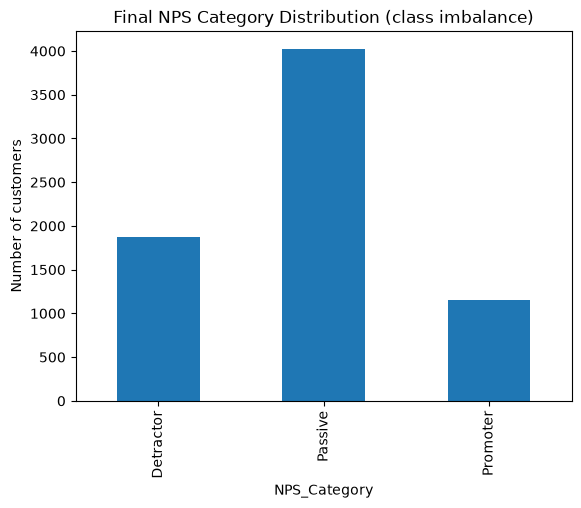

In [16]:
df_model["NPS_Category"].value_counts().reindex(["Detractor","Passive","Promoter"]).plot(kind="bar")
plt.title("Final NPS Category Distribution (class imbalance)")
plt.ylabel("Number of customers")
plt.show()

A ratio of 3.5 between the majority class (Passive) and the minority class (Promoter) is not extreme, but it is still significant for a 3-class ordinal problem.

Direct implication for modeling (`04_modeling`): accuracy alone would be misleading (a model that always predicts "Passive" would already achieve 57% accuracy without learning anything).

Therefore, the selected evaluation metrics are macro-F1, balanced accuracy, or quadratic weighted kappa (which accounts for class order), with a particular focus on recall for the Detractor class, which is the primary business target for retention.

## Final Feature Set

In [17]:
feature_cols = [c for c in df_model.columns if c != "NPS_Category"]
len(feature_cols)

24

In [18]:
feature_cols

['Customer ID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'n_services',
 'charges_per_service',
 'household_size_proxy',
 'is_autopay']

`Customer ID` is kept in the prepared dataset for traceability and demo interface purposes, but it will be explicitly excluded from the numerical features fed into the model in `04_modeling`.

### Output Files

In [19]:
df_model.to_csv("../data/processed/telco_nps_prepared.csv", index=False)
train_df.to_csv("../data/processed/telco_nps_train.csv", index=False)
test_df.to_csv("../data/processed/telco_nps_test.csv", index=False)

| File | Rows | Purpose |
|---|---|---|
| `telco_nps_prepared.csv` | 7043 | Full dataset, used for reference and fairness auditing |
| `telco_nps_train.csv` | 5634 | Model training |
| `telco_nps_test.csv` | 1409 | Evaluation set, simulating "silent" customers |

## Summary : Decisions & Limitations

- **Target:** Refined mapping (score 3 handled using `Churn Value`), documented and compared to the baseline mapping  31.7% of customers reclassified. Decision justified by business consistency (detractor rate aligned with churn rate).
- **Leakage:** `Satisfaction Score`, `Churn Score`, `Churn Value`, `Churn Label` excluded from features  used only to construct the target, never for prediction.
- **Cleaning:** `TotalCharges` corrected (11 values, tenure = 0 at 0.0), constant columns removed.
- **Split:** Stratified 80/20 split, with an explicitly documented limitation regarding potential selection bias between actual respondents and the silent population (not measurable in this dataset).
- **Class imbalance:** Ratio of 3.5, to be handled through metric selection in modeling rather than immediate resampling.
- **Out of scope:** Geographic features (missing Location file) acknowledged limitation, not an oversight.